### Imports


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch as t
from basin_volume import *
from tqdm.notebook import tqdm
from jaxtyping import Float

### Loading model & data

In [3]:
device = t.device("cuda:7" if t.cuda.is_available() else "cpu")
t.set_default_device(device)

In [4]:
torch.set_grad_enabled(False)

In [5]:
RUNS_DIR = "/mnt/ssd-1/adam/basin-volume/runs"

In [6]:
# model checkpoints are at 2^i, i\in [1,17]
models_clean = [
    load_convnext_checkpoint(RUNS_DIR + f"/b16pai_p001/checkpoint-{2**(step+1)}").to(
        device
    )
    for step in range(16)
]
models_poisoned = [
    load_convnext_checkpoint(RUNS_DIR + f"/b16pai_p4/checkpoint-{2**(step+1)}").to(
        device
    )
    for step in range(16)
]

In [7]:
cifar10_ds = load_cifar10_splits(size=1024)
val_ds = cifar10_ds["val"].to(device)
clean_ds = cifar10_ds["clean"].to(device)
poisoned_ds = cifar10_ds["poison"].to(device)

In [8]:
def model_to_flat_tensor(model):
    return torch.cat([param.flatten() for param in model.parameters()])


def flat_tensor_to_model(flat_tensor, model):
    pointer = 0
    with torch.no_grad():  # Prevent gradient tracking during reconstruction
        for param in model.parameters():
            numel = param.numel()
            # Convert to float16 during assignment to maintain consistency
            param.data = (
                flat_tensor[pointer : pointer + numel]
                .view_as(param)
                .to(dtype=t.float16)
            )
            pointer += numel

    # Clear any cached memory
    torch.cuda.empty_cache()
    return model

In [9]:
def logit_loss(p: Float[t.Tensor, "batch_size d_output"], q: Float[t.Tensor, ""]):
    log_p = p - torch.logsumexp(p, dim=-1, keepdim=True)  # log softmax of p
    log_q = q - torch.logsumexp(q, dim=-1, keepdim=True)  # log softmax of q

    # KL = sum(exp(log_p) * (log_p - log_q))
    return (log_p.exp() * (log_p - log_q)).sum(dim=-1).mean()

### Testing binary radius algorithm

In [10]:
def find_radius_vectorized_simple(
    center,
    directions: Float[t.Tensor, "batch_size d_params"],
    dataset: Float[t.Tensor, "batch_data 3 d_image d_image"],
    cutoff: Float,
    cost_fn,
    rtol=1e-1,
    init_mult=1,
    iters=10,
    jump=2.0,
):
    model_template = load_convnext_checkpoint(
        RUNS_DIR + f"/b16pai_p001/checkpoint-1"
    ).to(device)

    batch_size = directions.shape[0]

    mults = init_mult * torch.ones(batch_size, device=device)
    highs = torch.inf * torch.ones(batch_size, device=device)
    lows = torch.zeros(batch_size, device=device)

    model_center = flat_tensor_to_model(center, model_template)

    center = model_to_flat_tensor(model_center)

    logits_center = model_center(dataset)["logits"]  # batch_data x d_labels

    logits_directions = [
        flat_tensor_to_model(center + directions[i] * mults[i], model_template)(
            dataset
        )["logits"]
        for i in range(batch_size)
    ]

    costs = t.tensor(
        [cost_fn(logits_center, logits_directions[i]) for i in range(batch_size)]
    )

    deltas = costs

    while iters > 0 and any(abs(deltas - cutoff) > cutoff * rtol):

        logits_directions = [
            flat_tensor_to_model(center + directions[i] * mults[i], model_template)(
                dataset
            )["logits"]
            for i in range(batch_size)
        ]

        costs = torch.stack(
            [cost_fn(logits_center, logits_directions[i]) for i in range(batch_size)]
        )

        deltas = costs

        low = deltas < cutoff
        high = deltas > cutoff

        lows = torch.where(low, mults, lows)
        highs = torch.where(high, mults, highs)

        mults = torch.where(highs == torch.inf, mults * jump, (highs + lows) / 2)

        iters -= 1

    return mults, deltas

### Checking radius in terms of nats


In [29]:
center = model_to_flat_tensor(models_poisoned[-5])
directions = t.randn(3, center.shape[0])
directions = directions / directions.norm(dim=-1, keepdim=True)
cutoff = 0.1
mults, deltas = find_radius_vectorized_simple(
    center=center,
    directions=directions,
    dataset=poisoned_ds,
    cutoff=cutoff,
    cost_fn=logit_loss,
)

In [31]:
def plot_direction_cost(
    center,
    direction,
    mult,
    cost_fn,
    cutoff: Float,
    dataset: Float[t.Tensor, "batch_data 3 d_image d_image"],
    steps: int = 100,
    plot=True,
):

    sample_mistake = False

    model_template = load_convnext_checkpoint(
        RUNS_DIR + f"/b16pai_p001/checkpoint-1"
    ).to(device)

    model_center = flat_tensor_to_model(center, model_template)
    logits_center = model_center(dataset)["logits"]

    cost_list = []
    for i in range(steps):
        logits_directions = flat_tensor_to_model(
            center + direction * mult * i / steps, model_template
        )(dataset)["logits"]
        cost = cost_fn(logits_center, logits_directions)

        if cost > cutoff and i < steps - 10:
            sample_mistake = True

        cost_list.append(cost.cpu().numpy())
    if plot or sample_mistake:
        plt.plot(cost_list)
        plt.xlabel("Steps")
        plt.ylabel("Cost")
        plt.title("Cost vs Steps")
        plt.show()
    if sample_mistake:
        return direction, center, mult
    else:
        return 1

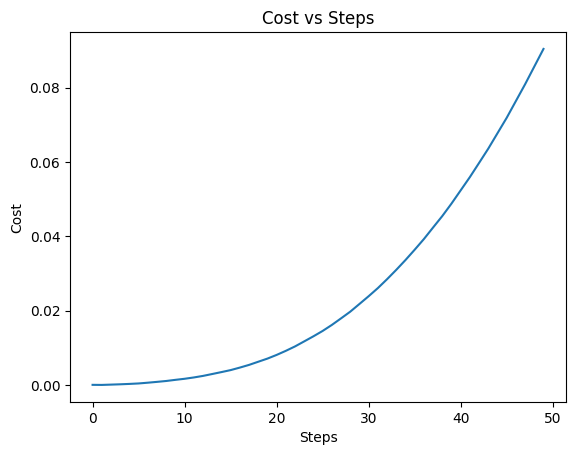

1

In [30]:
plot_direction_cost(
    center,
    direction=directions[1],
    mult=mults[1],
    cost_fn=logit_loss,
    dataset=poisoned_ds,
    steps=50,
    cutoff=cutoff,
)

  0%|          | 0/12 [00:00<?, ?it/s]

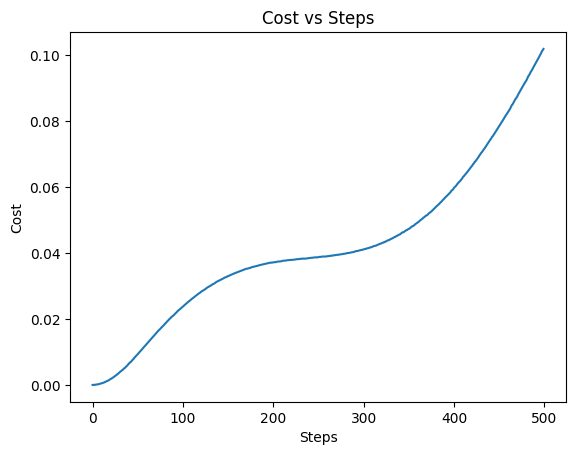

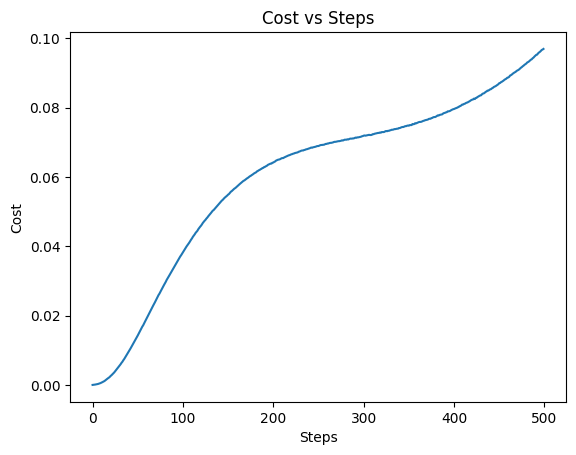

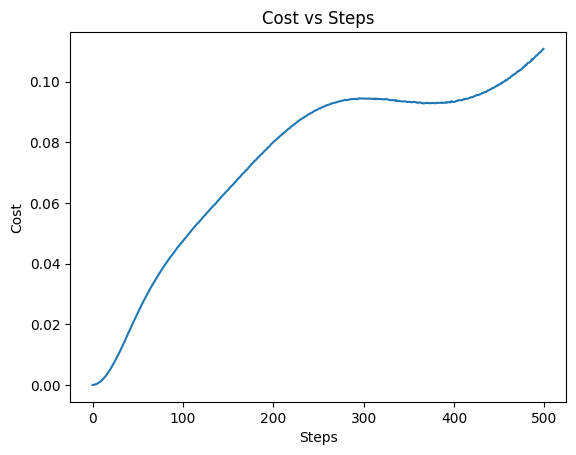

0 0 0 2


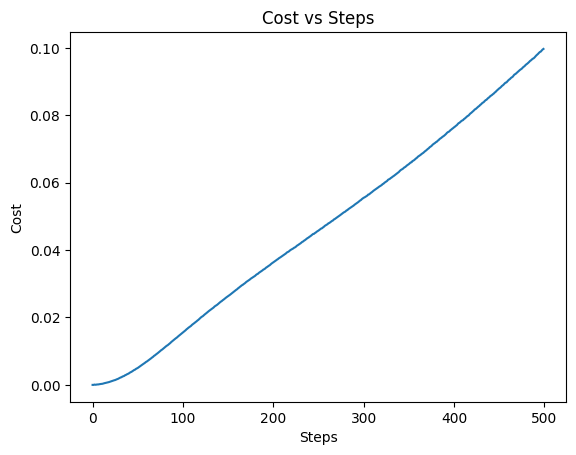

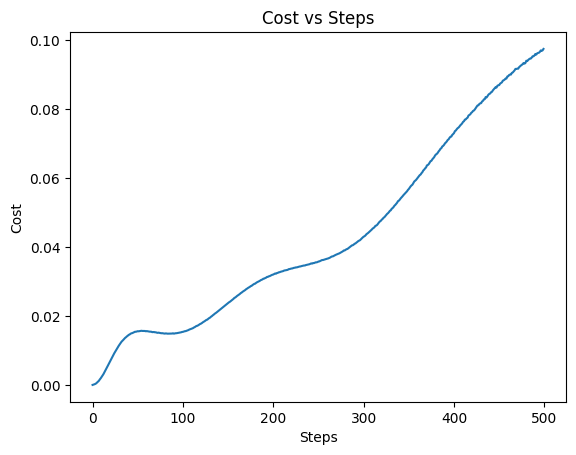

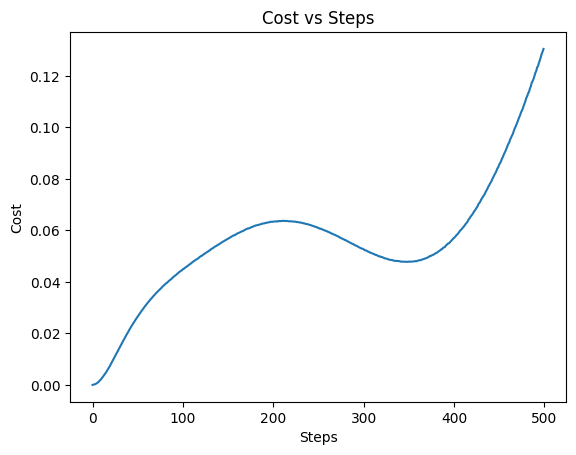

0 0 1 2


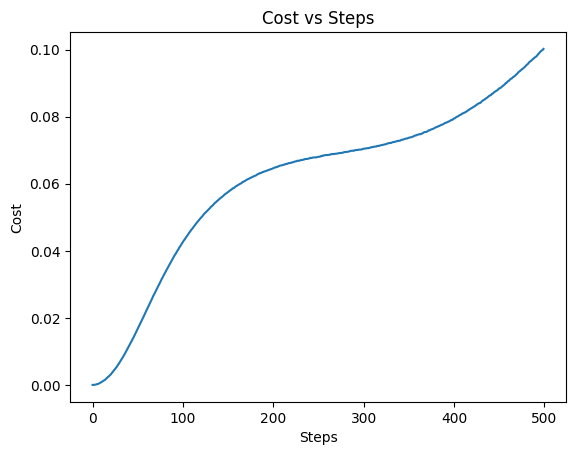

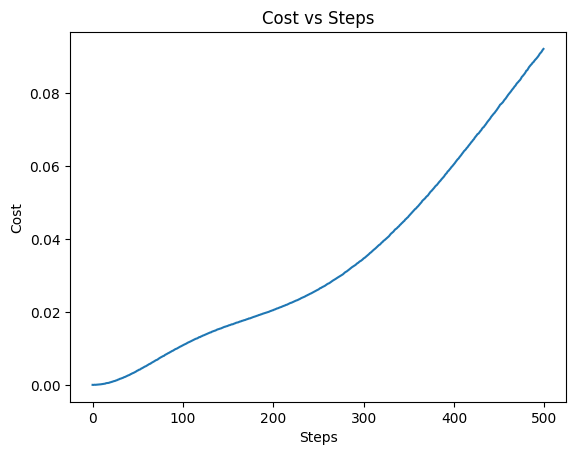

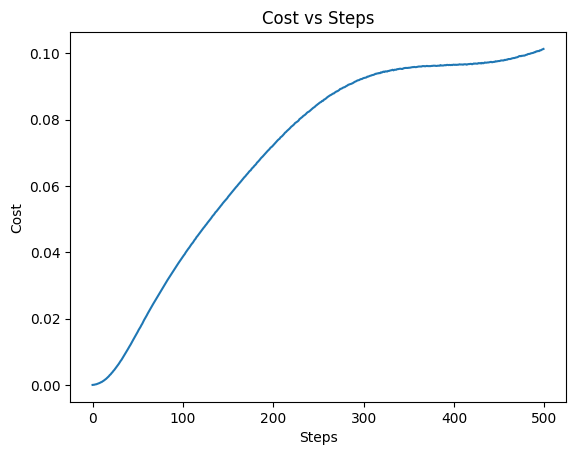

0 0 2 2


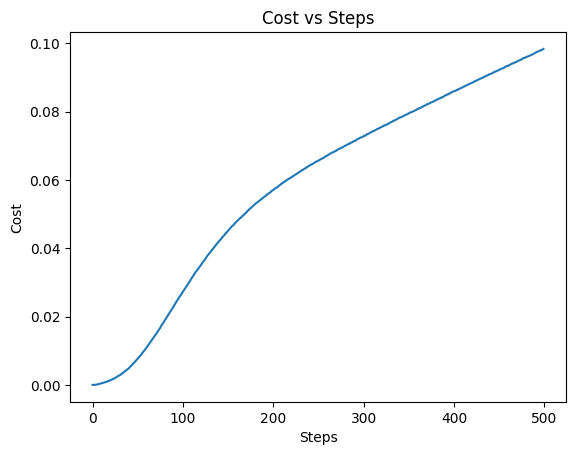

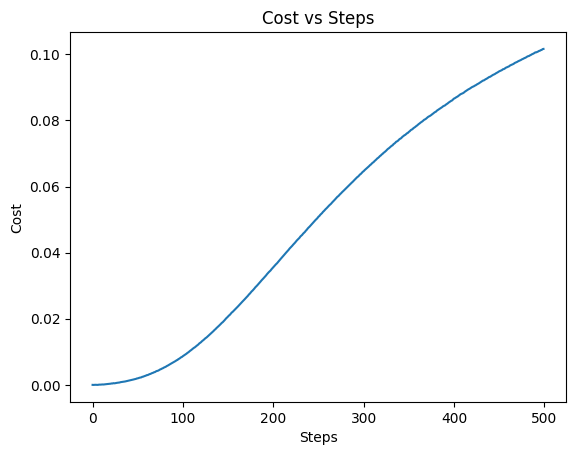

0 1 0 1


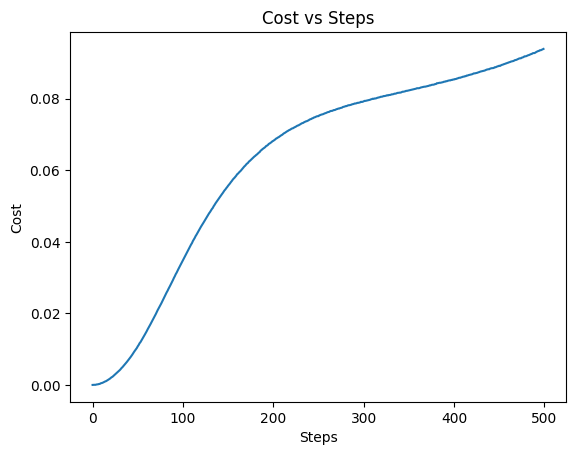

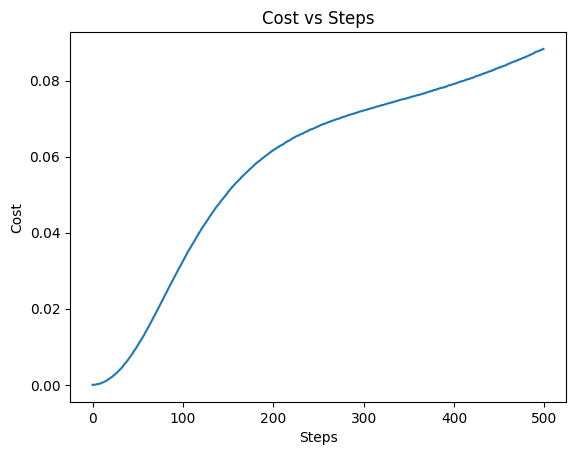

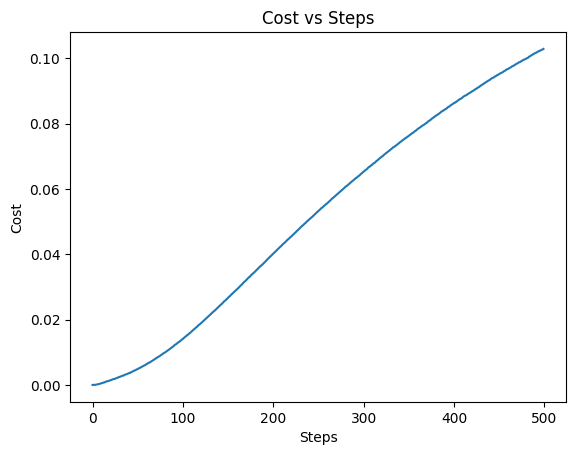

0 1 1 1


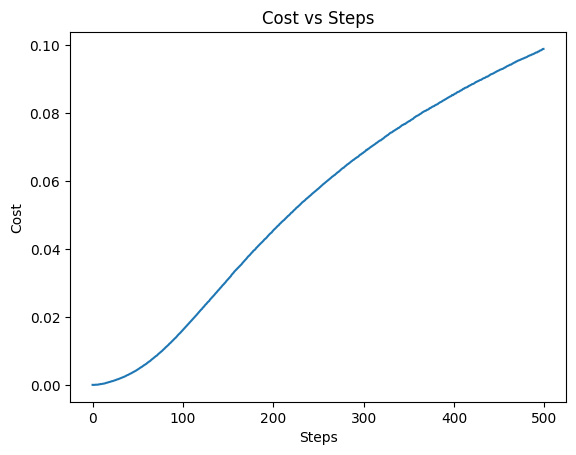

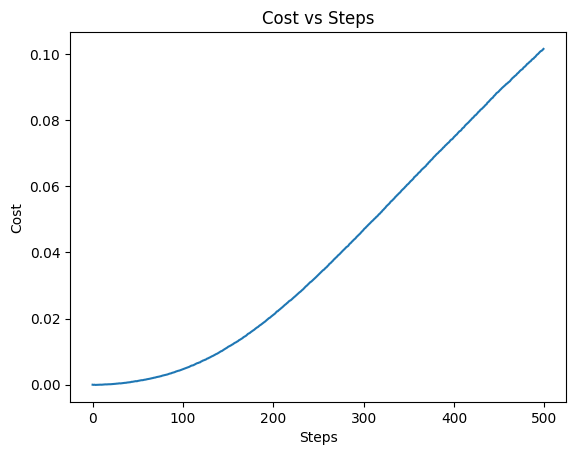

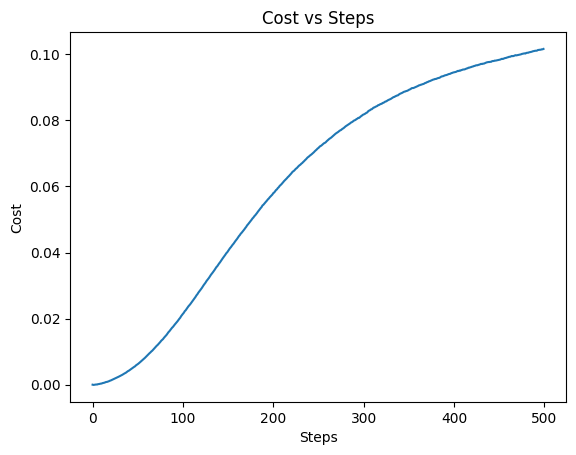

0 1 2 1


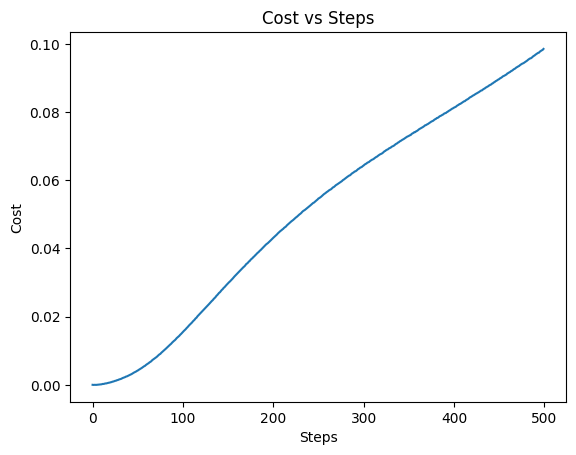

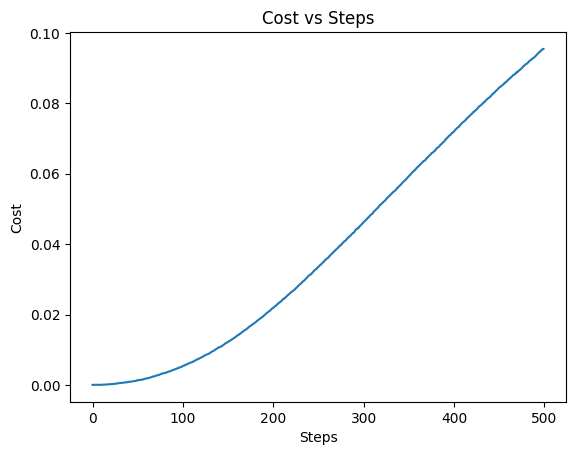

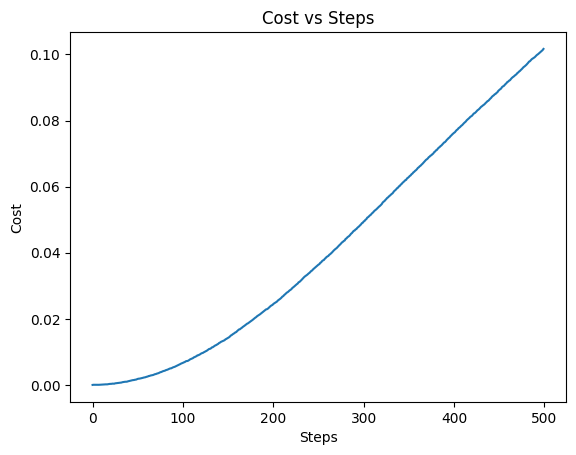

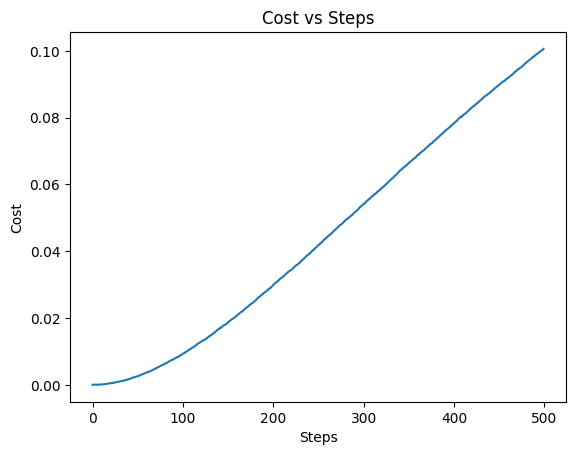

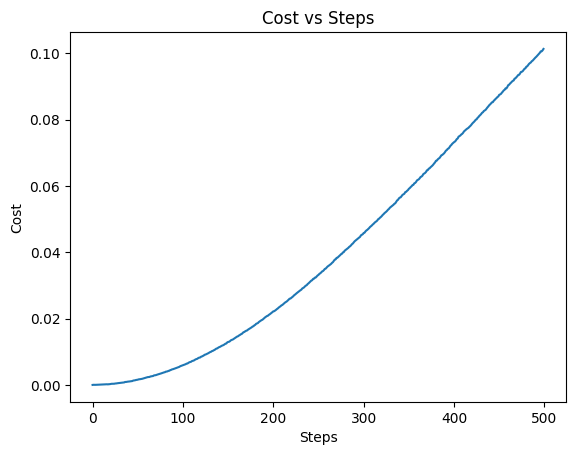

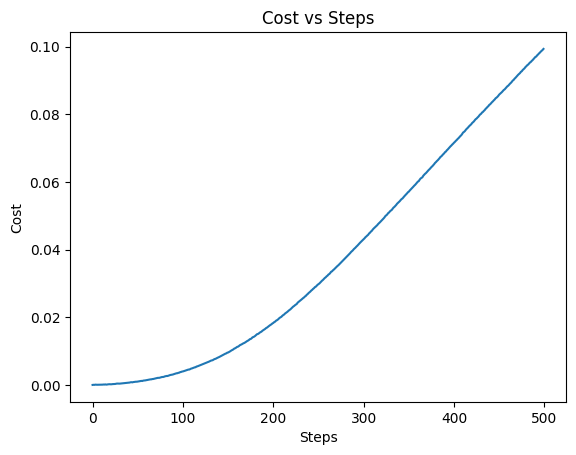

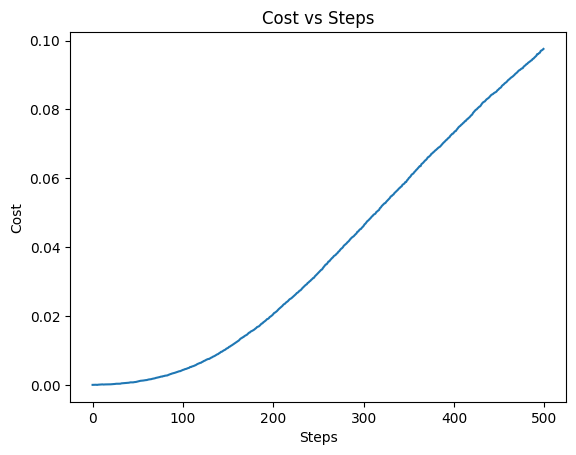

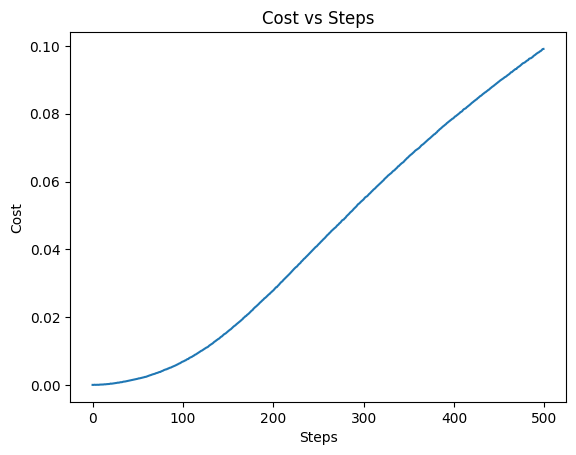

KeyboardInterrupt: 

In [34]:
history = []
for clean_or_poison in range(2):
    for i in tqdm(range(len(models_clean) - 4)):
        for d in range(len([clean_ds, poisoned_ds, val_ds])):

            dataset = [clean_ds, poisoned_ds, val_ds][d]
            model = (
                models_clean[i + 4] if clean_or_poison == 0 else models_poisoned[i + 4]
            )

            center = model_to_flat_tensor(model)

            directions = t.rand(3, center.shape[0])

            directions = directions / directions.norm(dim=-1, keepdim=True)
            cutoff = 0.1

            mults, deltas = find_radius_vectorized_simple(
                center=center,
                directions=directions,
                dataset=dataset,
                cutoff=cutoff,
                cost_fn=logit_loss,
            )

            for j in range(3):
                a = plot_direction_cost(
                    center,
                    direction=directions[j],
                    mult=mults[j],
                    cost_fn=logit_loss,
                    dataset=dataset,
                    steps=500,
                    cutoff=cutoff,
                    plot=True,
                )
                history.append(a)

                if a != 1:
                    print(clean_or_poison, i, d, j)

In [19]:
# find entry of history that is not 1
for i in range(len(history)):
    if history[i] != 1:
        print(i)
        break

17


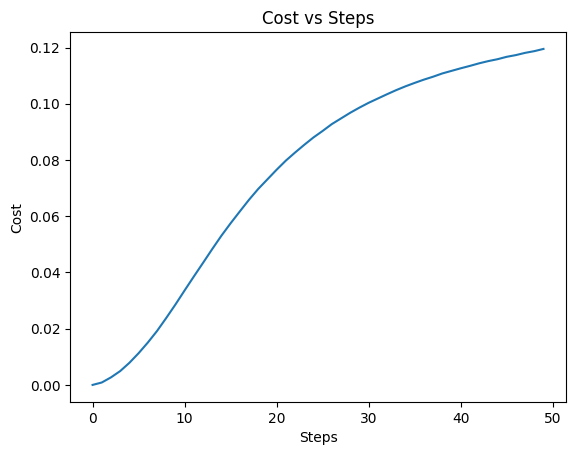

(tensor([0.0009, 0.0003, 0.0003,  ..., 0.0005, 0.0004, 0.0002], device='cuda:7'),
 tensor([-1.3512e-02, -2.6493e-03,  8.3389e-03,  ...,  7.6890e-06,
         -1.7881e-06,  2.0266e-06], device='cuda:7', dtype=torch.float16),
 tensor(32., device='cuda:7'))

In [22]:
plot_direction_cost(
    center=history[17][1],
    direction=history[17][0],
    mult=history[17][2],
    cost_fn=logit_loss,
    dataset=val_ds,
    steps=50,
    cutoff=cutoff,
    plot=True,
)

In [2]:
history[5]

In [16]:
for h in history:
    if h != 1:
        print(h)